### 1. Environment Setup

#### A. Importing Libraries

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn


print(f"Pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

Pandas version: 3.0.5
scikit-learn version: 1.9.0


#### B. Display Settings

In [2]:
# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

### 2. Data Loading and Schema Overview

#### A. Load Datasets

In [3]:
# === DATA PATH CONFIGURATION ===
# Local path
DATA_DIR = "./data"

# Verify data directory exists
if os.path.exists(DATA_DIR):
    print(f"✅ Data directory found: {DATA_DIR}")
    print(f"   Files: {os.listdir(DATA_DIR)}")
else:
    print(f"❌ Data directory not found: {DATA_DIR}")
    print("   Please update DATA_DIR to point to your Olist data folder")

✅ Data directory found: ./data
   Files: ['olist_sellers_dataset.csv', '.DS_Store', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


In [4]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data
olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols
Loaded reviews: 99,224 rows × 7 cols
Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


#### B. Schema Exploration - Overview of all tables

In [5]:
# Quick schema overview
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
            'Columns List': ', '.join(df.columns[:5]) + ('...' if len(df.columns) > 5 else '')
        })
    return pd.DataFrame(summary)

schema_summary(olist)

,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"99,441",8,25.85,"order_id, customer_id, order_status, order_pur..."
1,order_items,"112,650",7,30.98,"order_id, order_item_id, product_id, seller_id..."
2,customers,"99,441",5,27.88,"customer_id, customer_unique_id, customer_zip_..."
3,products,"32,951",9,6.60,"product_id, product_category_name, product_nam..."
4,sellers,"3,095",4,0.62,"seller_id, seller_zip_code_prefix, seller_city..."
5,payments,"103,886",5,17.02,"order_id, payment_sequential, payment_type, pa..."
6,reviews,"99,224",7,29.12,"review_id, order_id, review_score, review_comm..."
7,geolocation,"1,000,163",5,135.67,"geolocation_zip_code_prefix, geolocation_lat, ..."
8,category_translation,71,2,0.01,"product_category_name, product_category_name_e..."


### 3. Orders Table Exploration and Missingness Analysis

#### A. Orders Table - Sample

In [6]:
# Display first 5 rows of Orders Table
orders = olist['orders']
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


#### B. Shape and Summary

In [7]:
# Orders Table Summary
print("=== Shape ===")
print(f"{orders.shape}")
print("\n")
print("=== Summary ===")
orders.info()

=== Shape ===
(99441, 8)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


#### C. `order_status` Breakdown

In [8]:
print("=== Order Status Breakdown ===")
status_counts = orders['order_status'].value_counts()
status_pct = orders['order_status'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': status_counts, 'Percentage (%)': status_pct.round(2)}))

=== Order Status Breakdown ===
              Count  Percentage (%)
order_status                       
delivered     96478           97.02
shipped        1107            1.11
canceled        625            0.63
unavailable     609            0.61
invoiced        314            0.32
processing      301            0.30
created           5            0.01
approved          2            0.00


#### D. Missingness Breakdown

In [9]:
print("=== Columns with Missing Value ===")
null_dates = olist['orders'].isnull().sum()
print(null_dates[null_dates > 0])

=== Columns with Missing Value ===
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


#### E. Missingness: `order_delivered_customer_date`

In [10]:
# identifying rows where 'order_delivered_customer_date' is empty - returns True/False
is_blank = orders['order_delivered_customer_date'].isnull()

# filter to keep only rows where is_blank == True
blank_orders = orders[is_blank]

# group by order_status
blank_orders.groupby('order_status')['order_id'].count()

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_id, dtype: int64

##### Analysis - Why are there missing values in `order_delivered_customer_date`?

- 622 Orders (Status = Approved, Created, Invoiced, Processing (2 + 5 + 314 + 301)) are still in early warehouse fulfillment stage. They have not yet been dispatched yet.
- 619 Orders (Status = Canceled) are cancelled which means delivery never took place.
- 609 Orders (Status = Unavailable) are never fulfilled as the product is out of stock. No delivery took place.
- 1107 Orders (Status = Shipped) are in the midst of delivery. They have not yet reached customers
- 8 Orders (Status = Delivered) are orders with actual missing information. Need to handle these records. 

#### F. Missingness: `order_delivered_carrier_date`

In [11]:
# identifying rows where 'order_delivered_carrier_date' is empty - returns True/False
is_blank = orders['order_delivered_carrier_date'].isnull()

# filter to keep only rows where is_blank == True
blank_orders = orders[is_blank]

# group by order_status
blank_orders.groupby('order_status')['order_id'].count()

order_status
approved         2
canceled       550
created          5
delivered        2
invoiced       314
processing     301
unavailable    609
Name: order_id, dtype: int64

##### Analysis - Why are there missing values in `order_delivered_carrier_date`?

- 622 Orders (Status = Approved, Created, Invoiced, Processing (2 + 5 + 314 + 301)) are still in early warehouse fulfillment stage. They have not yet been dispatched yet.
- 550 Orders (Status = Canceled) are cancelled which means delivery never took place. This count is different (lesser) from the count in 'order_delivered_customer_date`. A possible reason is that the cancellation came after seller dropped off the product to the carrier (but before reaching the customer).
- 609 Orders (Status = Unavailable) are never fulfilled as the product is out of stock. No delivery took place.
- 2 Orders (Status = Delivered) are orders with actual missing information. Need to handle these records. 

#### G. Analysis: Overall
- **Pre-dispatch Cancellations (550 Orders):** Cancelled prior to courier handover. Both `order_delivered_carrier_date` and `order_delivered_customer_date` timestamps are missing.
- **In-transit Cancellations (69 Orders):** Difference ($619 - 550 = 69$) represents packages dispatched to carrier but cancelled before reaching the buyer.
- **Active Shipments (1,107 Orders):** Dispatched to carrier but still in transit. These have `order_delivered_carrier_date` timestamps but do not have `order_delivered_customer_date` timestamps.
- **Actual Missing Information (2 to 8 Orders):** These are completed deliveries that have missing `order_delivered_carrier_date` or `order_delivered_customer_date` or both.

##### Implications and Filtering Decision
- Because target variable for **Delivery Performance** requires measuring actual lead time from purchase to delivery ($\text{Delivered Date} - \text{Purchase Date}$), orders lacking a customer delivery date cannot be included.
- **Filtering Rule:** `order_status == 'delivered'` and `order_delivered_customer_date` is not null.
- **Rows retained:** 96,470 orders (need to exclude the 8 in the missingness analysis) which is about 97% of the total orders.

### 4. Orders Items Table Exploration and Missingness Analysis

#### A. Orders Items Table - Sample

In [12]:
# Display first 5 rows of Order Items Table
order_items = olist['order_items']
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


#### B. Shape and Summary

In [13]:
# Order Items Table Summary
print("=== Shape ===")
print(f"{order_items.shape}")
print("\n")
print("=== Summary ===")
order_items.info()

=== Shape ===
(112650, 7)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


#### C. Missingness Breakdown

In [14]:
print("=== Columns with Missing Value ===")
check_missing = order_items.isnull().sum()
print(check_missing[check_missing > 0])

=== Columns with Missing Value ===
Series([], dtype: int64)


#### D. Check Number of Unique Orders VS Total Number of Rows

In [15]:
unique_orders = order_items['order_id'].nunique()
total_rows = len(order_items)

print("=== Comparison ===")
print(f"Unique Orders: {unique_orders:,}")
print(f"Total Rows in Table: {total_rows:,}")
print(f"Number of Orders with Multiple Items: {total_rows - unique_orders:,}")


=== Comparison ===
Unique Orders: 98,666
Total Rows in Table: 112,650
Number of Orders with Multiple Items: 13,984


#### E. Number of Items Per Order

In [16]:
items_per_order = order_items.groupby('order_id')['order_item_id'].count()
items_per_order.value_counts().head(5)

order_item_id
1    88863
2     7516
3     1322
4      505
5      204
Name: count, dtype: int64

#### F. Orders with Multiple Sellers

In [17]:
sellers_per_order = order_items.groupby('order_id')['seller_id'].nunique()
multi_seller_orders = (sellers_per_order > 1).sum()

print(f"Total Unique Sellers: {order_items['seller_id'].nunique():,}")
print(f"Orders with Multiple Sellers: {multi_seller_orders:,}")

Total Unique Sellers: 3,095
Orders with Multiple Sellers: 1,278


#### G. Analysis in Order Items
- **Total Unique Sellers:** 3,095 sellers across Brazil.
- **Single-Seller Orders:** 98,666 - 1,278 = 97,388 orders (98.70%) involve only 1 seller.
- **Multi-Seller Orders:** 1,278 orders (1.30%) involve multiple distinct sellers fulfilling items in a single checkout.
- **Modeling Takeaway:** When aggregating `order_items` to the order level (`order_id`), we will engineer a feature (`seller_count`) to capture this dispatch complexity.

### 5. Customers Table Exploration and Missingness Analysis

#### A. Customers Table - Sample

In [18]:
# Display first 5 rows of Customers Table
customers = olist['customers']
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


#### B. Shape and Summary

In [19]:
# Customers Table Summary
print("=== Shape ===")
print(f"{customers.shape}")
print("\n")
print("=== Summary ===")
customers.info()

=== Shape ===
(99441, 5)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


#### C. Missingness Breakdown

In [20]:
print("=== Columns with Missing Value ===")
check_missing = customers.isnull().sum()
print(check_missing[check_missing > 0])

=== Columns with Missing Value ===
Series([], dtype: int64)


#### D. Key Uniqueness - Customer ID versus Customer Unique ID

In [21]:
unique_order_customers = customers['customer_id'].nunique()
unique_real_customers = customers['customer_unique_id'].nunique()

print(f"Unique customer_id (Per Order): {unique_order_customers:,}")
print(f"Unique customer_unique_id (Actual Customer): {unique_real_customers:,}")
print(f"Repeat Customer Count: {unique_order_customers - unique_real_customers:,}")

Unique customer_id (Per Order): 99,441
Unique customer_unique_id (Actual Customer): 96,096
Repeat Customer Count: 3,345


#### E. Validate that `customer_id` values match 1-to-1 between `Orders` and `Customers`

In [22]:
orders_cust_ids = set(orders['customer_id'])
customers_cust_ids = set(customers['customer_id'])

print(f"Total in orders: {len(orders_cust_ids):,}")
print(f"Total in customers: {len(customers_cust_ids):,}")
print(f"Matching customer_ids: {len(orders_cust_ids.intersection(customers_cust_ids)):,}")
print(f"Unmatched customer_ids: {len(orders_cust_ids.symmetric_difference(customers_cust_ids)):,}")

Total in orders: 99,441
Total in customers: 99,441
Matching customer_ids: 99,441
Unmatched customer_ids: 0


#### F. Analysis in Customers Table
- **Key Relationship:** `orders['customer_id']` maps 1-to-1 to `customers['customer_id']` (99,441 rows, 0 unmatched).
- **Customer Base:** 96,096 unique customer identities are represented in the customer table, indicating that relatively few customers placed multiple orders.
- **Geographic Data:** Provides destination ZIP code prefix (`customer_zip_code_prefix`), city, and state for computing customer-seller delivery distance.

### 6. Sellers Table Exploration and Missingness Analysis

#### A. Sellers Table - Sample

In [23]:
# Display first 5 rows of Sellers Table
sellers = olist['sellers']
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


#### B. Shape and Summary

In [24]:
# Sellers Table Summary
print("=== Shape ===")
print(f"{sellers.shape}")
print("\n")
print("=== Summary ===")
sellers.info()

=== Shape ===
(3095, 4)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


#### C. Missingness Breakdown

In [25]:
print("=== Columns with Missing Value ===")
check_missing = sellers.isnull().sum()
print(check_missing[check_missing > 0])

=== Columns with Missing Value ===
Series([], dtype: int64)


#### D. Check if all `seller_id` in `Order Items` table exists in `Sellers` table

In [26]:
# Check unique seller IDs across tables
unique_sellers_master = sellers['seller_id'].nunique()
unique_sellers_in_items = order_items['seller_id'].nunique()

# Check for unmatched IDs
unmatched_sellers = set(order_items['seller_id']) - set(sellers['seller_id'])

print(f"Total unique sellers in master list: {unique_sellers_master:,}")
print(f"Total unique sellers in order_items: {unique_sellers_in_items:,}")
print(f"Unmatched sellers (in items but not in master): {len(unmatched_sellers):,}")

Total unique sellers in master list: 3,095
Total unique sellers in order_items: 3,095
Unmatched sellers (in items but not in master): 0


#### E. Top Seller States and Cities

In [27]:
print("=== Top 5 Seller States ===")
seller_states = sellers['seller_state'].value_counts()
seller_states_pct = sellers['seller_state'].value_counts(normalize=True) * 100

df_s = pd.DataFrame({
    'Seller Count': seller_states,
    'Percentage (%)': seller_states_pct.round(2)
})

print(df_s.head())
print("\n")

print("=== Top 5 Seller Cities ===")
sellers['seller_city'].value_counts().head(5)

=== Top 5 Seller States ===
              Seller Count  Percentage (%)
seller_state                              
SP                    1849           59.74
PR                     349           11.28
MG                     244            7.88
SC                     190            6.14
RJ                     171            5.53


=== Top 5 Seller Cities ===


seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
Name: count, dtype: int64

#### F. Analysis in Sellers Table
- **State Clustering:** 59.74% of merchants reside in São Paulo (SP), and the top 5 states (SP, PR, MG, SC, RJ) account for 90.57% of all sellers.
- **Logistical Implication:** The concentration of sellers in the South/Southeast suggests that geographic distance may be relevant to delivery performance and will be investigated through seller-to-customer distance features.

### 7. Products Table Exploration and Missingness Analysis

#### A. Products Table - Sample

In [28]:
# Display first 5 rows of Products Table
products = olist['products']
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


#### B. Shape and Summary

In [29]:
# Products Table Summary
print("=== Shape ===")
print(f"{products.shape}")
print("\n")
print("=== Summary ===")
products.info()

=== Shape ===
(32951, 9)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


#### C. Missingness Breakdown

In [30]:
print("=== Columns with Missing Value ===")
check_missing = products.isnull().sum()
print(check_missing[check_missing > 0])

=== Columns with Missing Value ===
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


#### D. Analysis in Products Table
- **Completeness of Physical Specs:** Only 2 products (0.006%) lack weight and dimensional measurements (length, height, width).
- **Missing Categories:** 610 products (1.85%) lack category names and metadata, which will be labeled as `'unknown'`.
- **Logistical Relevance:** To determine whether product weight (`product_weight_g`) and volumetric size ($\text{length} \times \text{height} \times \text{width}$) affects delivery lead time.

### 8. Product Category Translation Table Exploration and Missingness Analysis

#### A. Product Category Translation Table - Sample

In [31]:
# Display first 5 rows of Product Category Translation Table
category_translation = olist['category_translation']
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


#### B. Shape and Summary

In [32]:
# Category Translation Table Summary
print("=== Shape ===")
print(f"{category_translation.shape}")
print("\n")
print("=== Summary ===")
category_translation.info()

=== Shape ===
(71, 2)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


#### C. Missingness Breakdown

In [33]:
print("=== Columns with Missing Value ===")
check_missing = category_translation.isnull().sum()
print(check_missing[check_missing > 0])

=== Columns with Missing Value ===
Series([], dtype: int64)


#### D. Verify Translation Coverage with Products Table

In [34]:
unique_portuguese_in_products = set(products['product_category_name'].dropna())
unique_portuguese_in_trans = set(category_translation['product_category_name'].dropna())

missing_trans = unique_portuguese_in_products - unique_portuguese_in_trans

print(f"Unique categories in products table: {len(unique_portuguese_in_products):,}")
print(f"Unique categories in translation table: {len(unique_portuguese_in_trans):,}")
print(f"Categories in products missing English: {len(missing_trans):,}")
if missing_trans:
    print(f"Unmapped categories: {missing_trans}")

Unique categories in products table: 73
Unique categories in translation table: 71
Categories in products missing English: 2
Unmapped categories: {'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}


#### E. Analysis in Category Translation Table
- **Translation Coverage:** 71 out of 73 Portuguese categories map directly to English translations.
- **Unmapped Categories (2):** `'portateis_cozinha_e_preparadores_de_alimentos'` and `'pc_gamer'` are absent from the translation lookup table.
- **Handling Strategy:** Manually include these two categories before merging the tables together.

### 9. Geolocation Table Exploration and Missingness Analysis

#### A. Geolocation Table - Sample

In [35]:
# Display first 5 rows of Geolocation Table
geolocation = olist['geolocation']
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


#### B. Shape and Summary

In [36]:
# Geolocation Table Summary
print("=== Shape ===")
print(f"{geolocation.shape}")
print("\n")
print("=== Summary ===")
geolocation.info()

=== Shape ===
(1000163, 5)


=== Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


#### C. Missingness Breakdown

In [37]:
print("=== Columns with Missing Value ===")
check_missing = geolocation.isnull().sum()
print(check_missing[check_missing > 0])

=== Columns with Missing Value ===
Series([], dtype: int64)


#### D. Unique Key - ZIP Code Prefix

In [38]:
print(f"Total Rows: {len(geolocation):,}")
print(f"Unique ZIP Code Prefixes: {geolocation['geolocation_zip_code_prefix'].nunique():,}")

Total Rows: 1,000,163
Unique ZIP Code Prefixes: 19,015


#### E. Minimum and Maximum Coordinates

In [39]:
print(f"=== Coordinate (Min vs Max) ===")
print(geolocation[['geolocation_lat','geolocation_lng']].describe())

=== Coordinate (Min vs Max) ===
       geolocation_lat  geolocation_lng
count       1000163.00       1000163.00
mean            -21.18           -46.39
std               5.72             4.27
min             -36.61          -101.47
25%             -23.60           -48.57
50%             -22.92           -46.64
75%             -19.98           -43.77
max              45.07           121.11


#### F. Analysis in Geolocation Table
- **Granularity:** The raw table contains 1,000,163 GPS readings across 19,015 unique 5-digit ZIP code prefixes.
- **Data Quality Anomaly Identified:** The raw dataset contains severe GPS coordinate entry errors (e.g., latitude > 40° placing points in North America/Europe, and longitude > 100° placing points in Asia). 
- **Remediation Plan:** In Section 10, we filter these coordinates using Brazil's geographic bounding box (Latitude [-34.0°, +5.5°], Longitude [-74.0°, -34.0°]) and compute 1 median coordinate pair per ZIP code prefix to build a reliable lookup dictionary.

### 10. Data Cleansing and Transformation

1. **Orders:** Filter to valid delivered orders with verified customer delivery dates (96,470 transactions).
2. **Products:** Retain missing physical measurements for later preprocessing and calculate product volumetric size where measurements are available.
3. **Category Translation:** Apply explicit fallback mapping for the 2 unmapped Portuguese categories (`portateis_cozinha_e_preparadores_de_alimentos` and `pc_gamer`).
4. **Geolocation:** Filter out-of-bounds GPS outliers (latitudes/longitudes outside Brazil) and deduplicate raw records into a 1-row-per-ZIP-prefix median coordinate lookup table.

#### A. Clean Orders Table: Filter for only valid delivered orders

In [40]:
# Conditions
is_delivered = orders['order_status'] == 'delivered'
has_delivery_date = orders['order_delivered_customer_date'].notna()

# Filtering
valid_orders_filter = is_delivered & has_delivery_date
orders_clean = orders[valid_orders_filter].copy()

# Summary/Count
total_count = len(orders)
retained_count = len(orders_clean)
dropped_count = total_count - retained_count

print(f"Total raw orders: {total_count:,}")
print(f"Retained delivered orders: {retained_count:,} ({retained_count/total_count*100:.2f}%)")
print(f"Filtered out: {dropped_count:,} ({ dropped_count/total_count*100:.2f}%)")


Total raw orders: 99,441
Retained delivered orders: 96,470 (97.01%)
Filtered out: 2,971 (2.99%)


In [41]:
# Confirm one row per order
print(f'Rows in orders_clean: {len(orders_clean):,}')
print(f'Unique order IDs: {orders_clean['order_id'].nunique():,}')

assert orders_clean['order_id'].is_unique

# Regression Target - Actual Delivery Lead Time in Days
orders_clean['actual_delivery_days'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']
).dt.total_seconds() / 86400.0

# Olist's Estimated Delivery Lead Time in Days
orders_clean['estimated_delivery_days'] = (
    orders_clean['order_estimated_delivery_date'] - orders_clean['order_purchase_timestamp']
).dt.total_seconds() / 86400.0

# Classification Target
# 1 = Late: delivered after the promised calendar date
# 0 = On-Time: delivered on or before the promised calendar date
orders_clean['is_late'] = (
    orders_clean['order_delivered_customer_date'].dt.date > orders_clean['order_estimated_delivery_date'].dt.date
).astype(int)

print(f'=== Order-Level Target Summary ===')
print(f'Number of orders: {len(orders_clean):,}')
print(f'Mean actual delivery days: {orders_clean['actual_delivery_days'].mean():.2f}')
print(f'Median actual delivery days: {orders_clean['actual_delivery_days'].median():.2f}')
print(f'Mean estimated delivery days: {orders_clean['estimated_delivery_days'].mean():.2f}')
print(f'Median estimated delivery days: {orders_clean['estimated_delivery_days'].median():.2f}')
print(f'Late delivery rate: {orders_clean['is_late'].mean() * 100:.2f}')

Rows in orders_clean: 96,470
Unique order IDs: 96,470
=== Order-Level Target Summary ===
Number of orders: 96,470
Mean actual delivery days: 12.56
Median actual delivery days: 10.22
Mean estimated delivery days: 23.74
Median estimated delivery days: 23.23
Late delivery rate: 6.77


In [42]:
orders_clean['is_late'].value_counts()

is_late
0    89936
1     6534
Name: count, dtype: int64

In [43]:
# validate constructed target variables
print(f'=== Target Validation ===')

print(f'Non-positive actual delivery durations: {(orders_clean['actual_delivery_days'] <= 0).sum()}')

print(f'Non-positive estimated delivery durations: {(orders_clean['estimated_delivery_days'] <= 0).sum()}')

display(orders_clean[['actual_delivery_days', 'estimated_delivery_days']].describe())

=== Target Validation ===
Non-positive actual delivery durations: 0
Non-positive estimated delivery durations: 0


,actual_delivery_days,estimated_delivery_days
count,96470.00,96470.00
mean,12.56,23.74
std,9.55,8.76
min,0.53,2.01
25%,6.77,18.33
50%,10.22,23.23
75%,15.72,28.41
max,209.63,155.14


#### B. Clean Products Table and Construct Product Features

In [44]:
products_clean = products.copy()

# drop columns not relevant to delivery performance
products_clean = products_clean.drop(columns=[
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty'
])

# fill in missing product category name
products_clean['product_category_name'] = products_clean['product_category_name'].fillna('unknown')

# compute product volume from physical dimensions
products_clean['product_volume_cm3'] = (
    products_clean['product_length_cm']
    * products_clean['product_width_cm']
    * products_clean['product_height_cm']
)

print(f'Cleaned Products Shape: {products_clean.shape}')

# check remaining missing values
check_missing = products_clean.isnull().sum()
print(check_missing[check_missing > 0])


Cleaned Products Shape: (32951, 7)
product_weight_g      2
product_length_cm     2
product_height_cm     2
product_width_cm      2
product_volume_cm3    2
dtype: int64


#### C. Clean Category Translation: Manually add missing mappings

In [45]:
# Unmapped categories: {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}
df_translation = pd.DataFrame({
    'product_category_name': [
        'portateis_cozinha_e_preparadores_de_alimentos', 
        'pc_gamer'
    ],
    'product_category_name_english': [
        'small_appliances_kitchen', 
        'pc_gamer'
    ]
})

category_translation_clean = pd.concat(
    [category_translation, df_translation], 
    ignore_index=True
)


#### D. Clean Geolocation: Coordinate Cleaning

In [46]:
valid_coords = (
    (geolocation['geolocation_lat'] >= -34.0) & (geolocation['geolocation_lat'] <= 5.5) &
    (geolocation['geolocation_lng'] >= -74.0) & (geolocation['geolocation_lng'] <= -34.0)
)

geolocation_clean = geolocation[valid_coords].copy()

geo_zip_lookup = geolocation_clean.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].median().reset_index()

print(f"=== Clean Geolocation Lookup Table ===")
print(f"Original rows: {len(geolocation):,}")
print(f"Cleaned unique ZIP codes: {len(geo_zip_lookup):,}")

geo_zip_lookup.head()

=== Clean Geolocation Lookup Table ===
Original rows: 1,000,163
Cleaned unique ZIP codes: 19,010


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.55,-46.63
1,1002,-23.55,-46.64
2,1003,-23.55,-46.64
3,1004,-23.55,-46.63
4,1005,-23.55,-46.64


### 11. Merging of Datasets

In [47]:
# aggregate order items to one row per order
order_items_features = (
    order_items.groupby('order_id').agg(
        item_count=('order_item_id', 'count'),
        product_count=('product_id', 'nunique'),
        seller_count=('seller_id', 'nunique'),
        total_price=('price', 'sum'),
        total_freight_value=('freight_value', 'sum')
    ).reset_index()
)

print(f'Order-item summary: {order_items_features.shape[0]:,} rows by {order_items_features.shape[1]:,} columns')

print(f'Unique order IDs: {order_items_features['order_id'].nunique():,}')

assert order_items_features['order_id'].is_unique

Order-item summary: 98,666 rows by 6 columns
Unique order IDs: 98,666


In [48]:
# merge orders table with order items table
df = orders_clean.merge(order_items_features, on='order_id', how='left', validate='one_to_one')

print(f'Merged dataset: {df.shape[0]:,} rows by {df.shape[1]:,} columns')
print(f'Unique order IDs: {df['order_id'].nunique():,}')

assert df['order_id'].is_unique

# check for missing order-item features after merge
order_item_cols = [
    'item_count',
    'product_count',
    'seller_count',
    'total_price',
    'total_freight_value'
]

print(df[order_item_cols].isnull().sum())

Merged dataset: 96,470 rows by 16 columns
Unique order IDs: 96,470
item_count             0
product_count          0
seller_count           0
total_price            0
total_freight_value    0
dtype: int64


In [49]:
# add product information to each order item
order_items_product = order_items.merge(products_clean, on='product_id', how='left', validate='many_to_one')

# aggregate product characteristics to one row per order
order_product_features = (
    order_items_product.groupby('order_id').agg(
        total_product_weight_g=('product_weight_g', sum),
        total_product_volume_cm3=('product_volume_cm3', sum)
    ).reset_index()
)

print(f'Order-product summary: {order_product_features.shape[0]:,} rows by {order_product_features.shape[1]:,} columns')

print(f'Unique order IDs: {order_product_features['order_id'].nunique():,}')

assert order_product_features['order_id'].is_unique

Order-product summary: 98,666 rows by 3 columns
Unique order IDs: 98,666


In [50]:
# merge product information to the dataframe
df = df.merge(order_product_features, on='order_id', how='left', validate='one_to_one')

print(f'Merged dataset: {df.shape[0]:,} rows by {df.shape[1]:,} columns')
print(f'Unique order IDs: {df['order_id'].nunique():,}')

assert df['order_id'].is_unique

# check for missing product related feature after merge
print(df[['total_product_weight_g', 'total_product_volume_cm3']].isnull().sum())

Merged dataset: 96,470 rows by 18 columns
Unique order IDs: 96,470
total_product_weight_g      16
total_product_volume_cm3    16
dtype: int64


In [51]:
# merge customer information

df = df.merge(customers[
    ['customer_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left',
    validate='many_to_one'
    )

print(f'After customer merge: {df.shape[0]:,} rows by {df.shape[1]:,} columns')
print(f'Unique order IDs: {df['order_id'].nunique():,}')

assert df['order_id'].is_unique

# check for unmatched customer records
print(
    df[['customer_zip_code_prefix', 'customer_city', 'customer_state']].isnull().sum()
)

After customer merge: 96,470 rows by 21 columns
Unique order IDs: 96,470
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [52]:
# add seller location to each order item
order_items_sellers = order_items.merge(
    sellers[['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']],
    on='seller_id', how='left', validate='many_to_one'
)

# aggregate seller information to one row per order
order_seller_features = (
    order_items_sellers.groupby('order_id').agg(
        seller_count_check=('seller_id', 'nunique'),
        seller_state_count=('seller_state', 'nunique'),
        seller_origin_state=('seller_state', lambda x: x.iloc[0] if x.nunique() == 1 else 'MULTI_STATE')
    ).reset_index()
)

print(f'Order-seller summary: {order_seller_features.shape[0]:,} rows by {order_seller_features.shape[1]:,} columns')
print(f'Unique order IDs: {order_seller_features['order_id'].nunique():,}')

assert order_seller_features['order_id'].is_unique

Order-seller summary: 98,666 rows by 4 columns
Unique order IDs: 98,666


In [53]:
# merge seller information to dataframe
df = df.merge(order_seller_features, on='order_id', how='left', validate='one_to_one')

print(f'After seller merge: {df.shape[0]:,} rows by {df.shape[1]:,} columns')
print(f'Unique order IDs: {df['order_id'].nunique():,}')

assert df['order_id'].is_unique

# check for unmatched seller records
print(
    'Seller count mismatches:',
    (df['seller_count'] != df['seller_count_check']).sum()
    )

After seller merge: 96,470 rows by 24 columns
Unique order IDs: 96,470
Seller count mismatches: 0


In [54]:
# drop temp column - seller_count_check
df = df.drop(columns='seller_count_check')

# final df
print(f'Final dataset shape: {df.shape}')
print('\nColumns:')
for col in df.columns:
    print(col)

Final dataset shape: (96470, 23)

Columns:
order_id
customer_id
order_status
order_purchase_timestamp
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
order_estimated_delivery_date
actual_delivery_days
estimated_delivery_days
is_late
item_count
product_count
seller_count
total_price
total_freight_value
total_product_weight_g
total_product_volume_cm3
customer_zip_code_prefix
customer_city
customer_state
seller_state_count
seller_origin_state


In [55]:
display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_delivery_days,estimated_delivery_days,is_late,item_count,product_count,seller_count,total_price,total_freight_value,total_product_weight_g,total_product_volume_cm3,customer_zip_code_prefix,customer_city,customer_state,seller_state_count,seller_origin_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.44,15.54,0,1,1,1,29.99,8.72,500.00,1976.00,3149,sao paulo,SP,1,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.78,19.14,0,1,1,1,118.70,22.76,400.00,4693.00,47813,barreiras,BA,1,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.39,26.64,0,1,1,1,159.90,19.22,420.00,9576.00,75265,vianopolis,GO,1,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.21,26.19,0,1,1,1,45.00,27.20,450.00,6000.00,59296,sao goncalo do amarante,RN,1,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.87,12.11,0,1,1,1,19.90,8.72,250.00,11475.00,9195,santo andre,SP,1,SP


In [56]:
# Structural checks
print(f'Number of rows: {len(df):,}')
print(f'Unique orders: {df['order_id'].nunique():,}')
print(f'Duplicated order IDs: {df['order_id'].duplicated().sum()}')

print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0])

Number of rows: 96,470
Unique orders: 96,470
Duplicated order IDs: 0

Missing values:
order_approved_at               14
order_delivered_carrier_date     1
total_product_weight_g          16
total_product_volume_cm3        16
dtype: int64


Final data quality check: The analytical dataset contains 96,470 unique delivered orders with no duplicated order IDs. Remaining missing values in approval/carrier timestamps relate to post-checkout variables that will not be used as predictors. The 16 missing product weight and volume values originate from missing physical measurements in the source product data and are retained for later preprocessing if these features are used in modelling.

### 12. Exploratory Data Analysis

#### A. Actual and Estimated Delivery Lead Time

In [57]:
delivery_summary = df[
    ['actual_delivery_days', 'estimated_delivery_days']
    ].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

display(delivery_summary)

,actual_delivery_days,estimated_delivery_days
count,96470.00,96470.00
mean,12.56,23.74
std,9.55,8.76
min,0.53,2.01
25%,6.77,18.33
50%,10.22,23.23
75%,15.72,28.41
90%,23.10,34.29
95%,29.27,38.42
99%,46.05,50.21


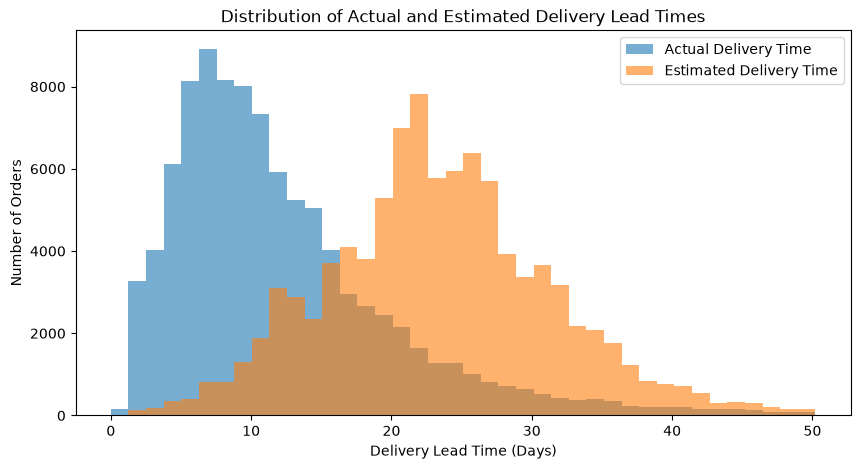

In [58]:
# display distribution up to 99th percentile
# only 1% of the orders exceed 46 days
 
actual_99 = df['actual_delivery_days'].quantile(0.99)
estimated_99 = df['estimated_delivery_days'].quantile(0.99)
plot_limit = max(actual_99, estimated_99)

plt.figure(figsize=(10,5))

plt.hist(
    df['actual_delivery_days'],
    bins=40,
    range=(0, plot_limit),
    alpha=0.6,
    label='Actual Delivery Time'
)

plt.hist(
    df['estimated_delivery_days'],
    bins=40,
    range=(0, plot_limit),
    alpha=0.6,
    label='Estimated Delivery Time'
)

plt.xlabel('Delivery Lead Time (Days)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Actual and Estimated Delivery Lead Times')
plt.legend()

plt.show()

##### Observations

- Actual delivery times are concentrated much earlier, around 5 to 15 days
- Estimated delivery times are concentrated later, around 20 to 30 days.
- Actual delivery lead times are generally shorter than the estimated delivery lead times provided for orders.

- Median actual delivery time = 10.22 days
- Median estimated delivery time = 23.23 days
- Mean actual delivery time = 12.56 days
- Mean estimated delivery time = 23.74 days

- The median actual delivery lead time is 10.22 days compared with a median estimated lead time of 23.23 days suggests that estimated delivery timelines are generally conservative (contains buffer) relative to observed delivery performance.

- Actual delivery time is right-skewed (mean 12.56 versus median 10.22).
- Most deliveries happen relatively quickly but there is a long tail of orders that take much longer.

#### B. Classification Target Distribution - Class Imbalance

In [59]:
late_counts = df['is_late'].value_counts()
late_percentages = (df['is_late'].value_counts() / len(df))* 100

class_labels = ['On Time', 'Late']

print('=== Late Delivery Class Distribution ===')
for i, label in enumerate(class_labels):
    print(f'{label}: {late_counts.iloc[i]:,} orders ({late_percentages.iloc[i]:.2f}%)')



=== Late Delivery Class Distribution ===
On Time: 89,936 orders (93.23%)
Late: 6,534 orders (6.77%)


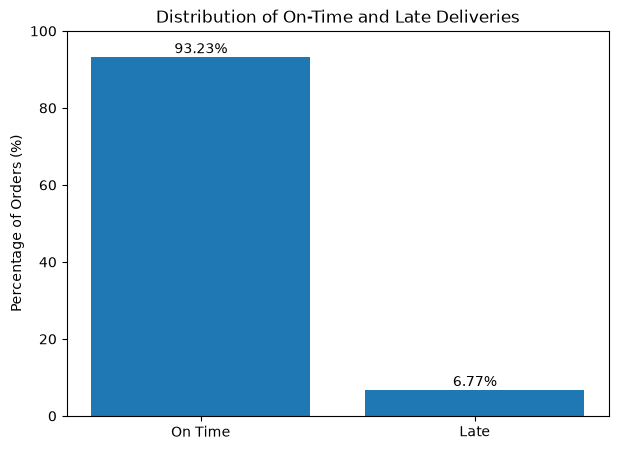

In [60]:
plt.figure(figsize=(7,5))

bars = plt.bar(class_labels, late_percentages.values)

plt.ylabel('Percentage of Orders (%)')
plt.title('Distribution of On-Time and Late Deliveries')
plt.ylim(0,100)

for bar, percentage in zip(bars, late_percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{percentage:.2f}%',
        ha='center'
    )

plt.show()

##### Observations

- Classification target is highly imbalanced.
- Of the 96,470 delivered orders, 93.23% were delivered on time.
- Only 6.77% were delivered late.

- Classification performance should not be assessed using accuracy alone. 
- Because a model predicting every order as on time would achieve high accuracy, but fail to identify any late deliveries.


#### C. Multi-Seller and Multi-State Orders

Orders involving multiple sellers may be more complex to fulfil.
Hence examining the number of orders involving multiple sellers and sellers located across multiple states. 

In [61]:
multi_seller = df['seller_count'] > 1
multi_state = df['seller_state_count'] > 1

print('=== Seller Composition of Orders ===')
print(f'Multiple sellers: {multi_seller.sum():,} orders {multi_seller.mean() * 100:.2f}%')
print(f'Multiple seller states: {multi_state.sum():,} orders {multi_state.mean() * 100:.2f}%')

display(df['seller_count'].value_counts())

display(df['seller_state_count'].value_counts())

=== Seller Composition of Orders ===
Multiple sellers: 1,275 orders 1.32%
Multiple seller states: 509 orders 0.53%


seller_count
1    95195
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

seller_state_count
1    95961
2      502
3        7
Name: count, dtype: int64

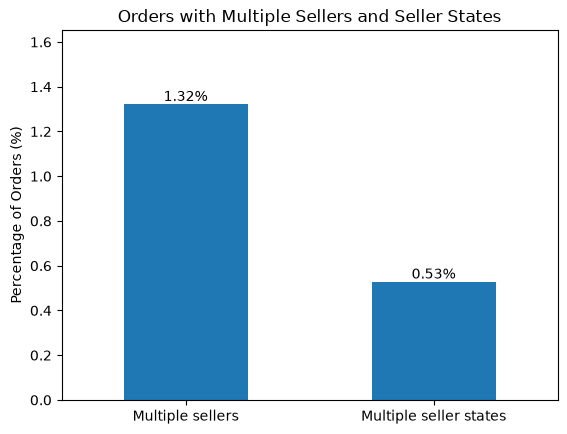

In [62]:
multi_seller_pct = (df['seller_count'] > 1).mean() * 100
multi_state_pct = (df['seller_state_count'] > 1).mean() * 100

seller_structure_pct = pd.Series({
    'Multiple sellers': multi_seller_pct,
    'Multiple seller states': multi_state_pct
})

ax = seller_structure_pct.plot(kind='bar')

ax.set_ylabel('Percentage of Orders (%)')
ax.set_title('Orders with Multiple Sellers and Seller States')
ax.set_ylim(0, max(seller_structure_pct) * 1.25)

for i, value in enumerate(seller_structure_pct):
    ax.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.show()


##### Observation:

- Most orders involve only one seller (98.68%), while 1.32% involve multiple sellers.
- Orders involving sellers from multiple states are even less common, only 0.53% of orders.

#### Are multi-seller or multi-state orders associated with worse delivery performance?

In [63]:
seller_complexity = df.assign(
    seller_group=np.where(
        df['seller_count'] > 1,
        'Multiple Sellers',
        'Single Seller'
    ),
    seller_state_group=np.where(
        df['seller_state_count'] > 1,
        'Multiple Seller States',
        'Single Seller State'
    )
)

seller_performance = (
    seller_complexity
    .groupby('seller_group')
    .agg(
        Orders=('order_id', 'count'),
        Median_Delivery_Days=('actual_delivery_days', 'median'),
        Mean_Delivery_Days=('actual_delivery_days', 'mean'),
        Late_Rate=('is_late', 'mean')
    )
    .reset_index()
    .rename(columns={'seller_group': 'Seller Group'})
)

seller_performance['Late_Rate'] *= 100


state_performance = (
    seller_complexity
    .groupby('seller_state_group')
    .agg(
        Orders=('order_id', 'count'),
        Median_Delivery_Days=('actual_delivery_days', 'median'),
        Mean_Delivery_Days=('actual_delivery_days', 'mean'),
        Late_Rate=('is_late', 'mean')
    )
    .reset_index()
    .rename(columns={'seller_state_group': 'Seller Group'})
)

state_performance['Late_Rate'] *= 100

# make the display nicer by removing the underscores
column_names = {
    'Median_Delivery_Days': 'Median Delivery (Days)',
    'Mean_Delivery_Days': 'Mean Delivery (Days)',
    'Late_Rate': 'Late Rate'
}

# Display seller-count comparison
display(
    seller_performance
    .rename(columns=column_names)
    .style
    .format({
        'Orders': '{:,.0f}',
        'Median Delivery (Days)': '{:.2f}',
        'Mean Delivery (Days)': '{:.2f}',
        'Late Rate': '{:.2f}%'
    })
    .set_caption('Delivery Performance by Number of Sellers')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-weight', 'bold'),
            ('text-align', 'left')
        ]}
    ])
    .hide(axis='index')
)

# Display seller-state comparison
display(
    state_performance
    .rename(columns=column_names)
    .style
    .format({
        'Orders': '{:,.0f}',
        'Median Delivery (Days)': '{:.2f}',
        'Mean Delivery (Days)': '{:.2f}',
        'Late Rate': '{:.2f}%'
    })
    .set_caption('Delivery Performance by Seller-State Composition')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-weight', 'bold'),
            ('text-align', 'left')
        ]}
    ])
    .hide(axis='index')
)

Seller Group,Orders,Median Delivery (Days),Mean Delivery (Days),Late Rate
Multiple Sellers,"1,275",7.93,9.14,1.02%
Single Seller,"95,195",10.25,12.60,6.85%


Seller Group,Orders,Median Delivery (Days),Mean Delivery (Days),Late Rate
Multiple Seller States,509,7.83,8.95,0.59%
Single Seller State,"95,961",10.23,12.58,6.81%


##### Observations:

Multiple-Seller Orders:
- Median delivery: 7.93 days vs 10.25 days (Single seller orders)
- Mean delivery: 9.14 days vs 12.60 days
- Late rate: 1.02% vs 6.85%

Multiple-State Orders:
- Median delivery: 7.83 days vs 10.23 days (Single seller orders)
- Mean delivery: 8.95 days vs 12.58 days
- Late rate: 0.59% vs 6.81%

Comments:
- Multi-seller and multi-state orders do not appear to have poorer delivery performance.
- However these groups only account for 1.32% and 0.53% of all orders respectively.
- Does not necessary imply having multi-sellers or seller states cause better delivery performance.

#### D. Delivery Performance Over Time

Delivery performance is examined over time to identify whether actual delivery lead times and late-delivery rates vary across the period covered by the dataset.

In [64]:
# Create purchase month for temporal EDA
temporal_eda = df.copy()

temporal_eda['purchase_month'] = (
    temporal_eda['order_purchase_timestamp']
    .dt.to_period('M')
)

monthly_performance = (
    temporal_eda
    .groupby('purchase_month')
    .agg(
        orders=('order_id', 'count'),
        median_delivery_days=('actual_delivery_days', 'median'),
        mean_delivery_days=('actual_delivery_days', 'mean'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
)

monthly_performance['late_rate'] *= 100

display(monthly_performance.round(2))

/var/folders/6n/w5hly7ls3lzbcjtc6jpp6_r40000gn/T/ipykernel_8244/1957709888.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(monthly_performance.round(2))


,purchase_month,orders,median_delivery_days,mean_delivery_days,late_rate
0,2016-09,1,54.81,54.81,100.00
1,2016-10,265,17.94,19.60,0.75
2,2016-12,1,4.69,4.69,0.00
3,2017-01,750,10.73,12.65,2.93
4,2017-02,1653,10.97,13.17,2.96
5,2017-03,2546,10.13,12.95,4.56
6,2017-04,2303,12.75,14.92,6.56
7,2017-05,3545,9.79,11.32,2.99
8,2017-06,3135,10.80,12.01,3.03
9,2017-07,3872,10.16,11.59,2.79


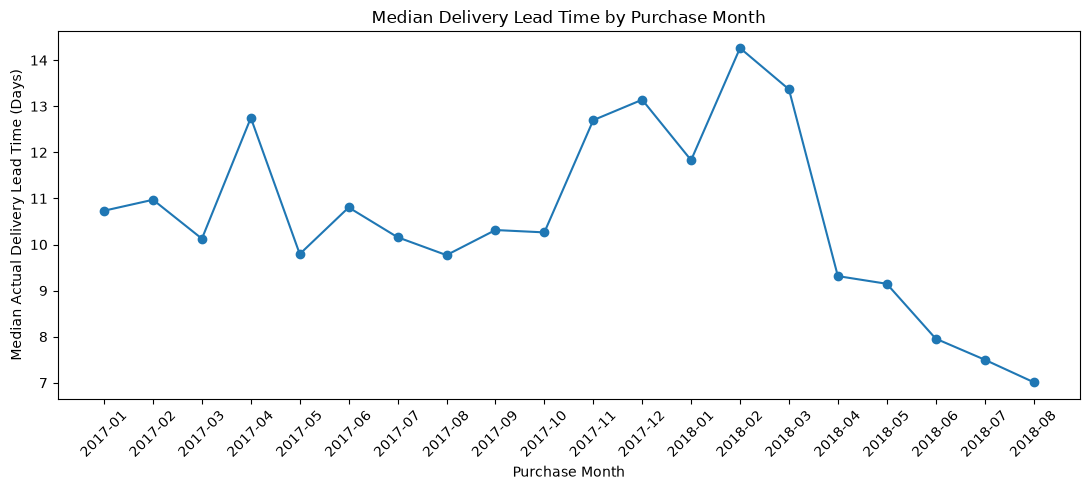

In [65]:
# Focus the visualization on the period with consistent monthly order volume
monthly_plot = monthly_performance[
    monthly_performance['purchase_month'] >= pd.Period('2017-01', freq='M')
].copy()

monthly_plot['purchase_month_label'] = (
    monthly_plot['purchase_month'].astype(str)
)

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_plot['purchase_month_label'],
    monthly_plot['median_delivery_days'],
    marker='o'
)

plt.xlabel('Purchase Month')
plt.ylabel('Median Actual Delivery Lead Time (Days)')
plt.title('Median Delivery Lead Time by Purchase Month')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

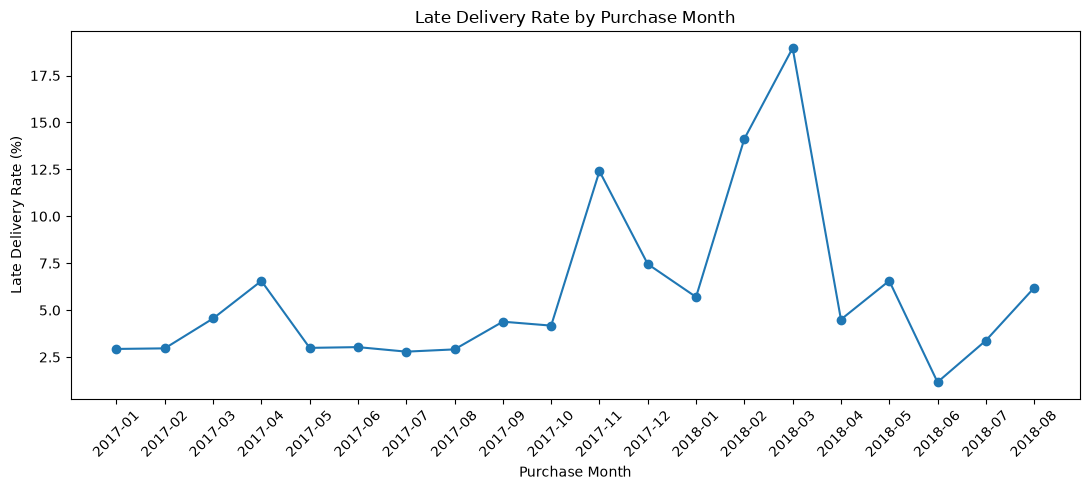

In [66]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_plot['purchase_month_label'],
    monthly_plot['late_rate'],
    marker='o'
)

plt.xlabel('Purchase Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Purchase Month')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

##### Observations

- Delivery performance varies across the observed months, although the dataset does not cover enough complete years to establish a recurring seasonal pattern.
- Median delivery lead time and late-delivery rates increased during some periods, particularly in late 2017 and early 2018, before declining later in 2018.

- Median actual delivery lead time increased during late 2017 and early 2018, reaching 14.26 days in February 2018, before declining to 7.01 days by August 2018.
- Late delivery rates also varied substantially, reaching 12.40% in November 2017 and peaking at 18.96% in March 2018.
- However, the temporal patterns of delivery lead time and late delivery rate do not fully coincide.
- This further demonstrates that longer delivery duration does not necessarily mean that an order was delivered late relative to its promised date.

#### E. Weight and Volume Impact on Delivery Performance

Do orders with heavier products show different delivery performance?

In [67]:
weight_eda = df[
    df['total_product_weight_g'].notna()
].copy()

weight_eda['weight_group'] = pd.qcut(
    weight_eda['total_product_weight_g'],
    q=5,
    duplicates='drop'
)

weight_performance = (
    weight_eda
    .groupby('weight_group', observed=True)
    .agg(
        orders=('order_id', 'count'),
        median_weight_g=('total_product_weight_g', 'median'),
        median_delivery_days=('actual_delivery_days', 'median'),
        late_rate=('is_late', 'mean')
    )
    .reset_index()
)

weight_performance['late_rate'] *= 100

display(weight_performance.round(2))

,weight_group,orders,median_weight_g,median_delivery_days,late_rate
0,"(-0.001, 250.0]",20498,183.00,9.43,6.08
1,"(250.0, 500.0]",18331,375.00,9.98,7.02
2,"(500.0, 1100.0]",19055,750.00,10.13,6.25
3,"(1100.0, 2800.0]",19419,1650.00,10.45,7.03
4,"(2800.0, 184400.0]",19151,6600.00,11.20,7.55


##### Observations:

- Product weight shows a modest relationship with actual delivery lead time.
- Median delivery time generally increases across the weight groups, from 9.43 days for the lightest group to 11.20 days for the heaviest group.
- The relationship with late delivery rate is less consistent.
- This suggests that product weight may contain some useful information for predicting delivery duration, but further investigations would be required to assess its predictive value.

### 13. Baseline Metrics

#### A. Train / Validation / Test Split

The dataset is split chronologically using `order_purchase_timestamp`, with 70% of
orders used for training, 15% for validation and 15% for testing.

A chronological split is used because the intended prediction setting is operational:
the model will use historical orders to make predictions for future orders at the time
of purchase. Keeping later orders in the validation and test sets therefore provides
a more realistic evaluation than randomly mixing earlier and later orders.

The validation set will be used during model development and comparison, while the
test set will remain untouched until the final model evaluation.

Since the classification target is imbalanced, the proportion and number of late
orders are checked after the chronological split. The data are not stratified because
doing so could disrupt the temporal ordering. The naturally occurring class
distribution is retained in each period.

No random seed is required for the train/validation/test split because the data are
split deterministically according to chronological order rather than through random
sampling. A fixed random seed will be set and documented for any later modelling or
resampling procedures that involve randomness, to ensure reproducibility.

In [68]:
# sort orders chronologically by purchase timestamp
df_model = (
    df
    .sort_values('order_purchase_timestamp')
    .reset_index(drop=True)
)

# define 70/15/15 split points
n = len(df_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

# create chronological train, validation and test sets
train_df = df_model.iloc[:train_end].copy()
validation_df = df_model.iloc[train_end:validation_end].copy()
test_df = df_model.iloc[validation_end:].copy()

In [69]:
# check date range and class distribution of each split
# because split is based on chronological order, the percentage of late orders is not expected
# to be identical across the three split datasets
def describe_split(name, data):
    print(f"{name}")
    print(f"Orders: {len(data):,}")
    print(
        # check that chronological order is correct
        f"Date range: "
        f"{data['order_purchase_timestamp'].min().date()} "
        f"to {data['order_purchase_timestamp'].max().date()}"
    )

    # check that each set still contains enough late orders for classification evaluation
    class_counts = data['is_late'].value_counts().sort_index()
    class_pct = data['is_late'].value_counts(
        normalize=True
    ).sort_index() * 100

    print(
        f"On time: {class_counts.get(0, 0):,} "
        f"({class_pct.get(0, 0):.2f}%)"
    )
    print(
        f"Late:    {class_counts.get(1, 0):,} "
        f"({class_pct.get(1, 0):.2f}%)"
    )
    print()


describe_split("TRAIN", train_df)
describe_split("VALIDATION", validation_df)
describe_split("TEST", test_df)

TRAIN
Orders: 67,529
Date range: 2016-09-15 to 2018-04-15
On time: 62,239 (92.17%)
Late:    5,290 (7.83%)

VALIDATION
Orders: 14,470
Date range: 2018-04-15 to 2018-06-21
On time: 13,846 (95.69%)
Late:    624 (4.31%)

TEST
Orders: 14,471
Date range: 2018-06-21 to 2018-08-29
On time: 13,851 (95.72%)
Late:    620 (4.28%)



**Split check:**  
The chronological split produced 67,529 training orders, 14,470 validation orders
and 14,471 test orders. The late-delivery rate decreased from 7.83% in training to
4.31% in validation and 4.28% in testing. However, the validation and test sets still
contain 624 and 620 late orders respectively, providing sufficient minority-class
observations for evaluation.

The difference in class proportions is retained rather than artificially balanced,
as it reflects the naturally observed distribution across the different time periods.

#### B. Regression Baseline

The regression baseline uses the historical median delivery lead time from the training set as a constant prediction for all validation orders.

The median is used instead of the mean because the delivery lead time distribution is right-skewed and contains a long tail. The median is therefore less sensitive to unusually long delivery times.

The baseline is evaluated on the validation set using MAE as the primary metric and RMSE as the secondary metric.

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# learn the baseline prediction from the training set only
baseline_median = train_df['actual_delivery_days'].median()

# actual regression target values in the validation set
y_val_reg = validation_df['actual_delivery_days']

# predict the same historical median delivery time for every validation order
y_pred_reg = np.full(len(validation_df), baseline_median)

# evalulate the baseline prediction
baseline_mae = mean_absolute_error(y_val_reg, y_pred_reg)
mse = mean_squared_error(y_val_reg, y_pred_reg)
baseline_rmse = np.sqrt(mse)

print(f'Training median delivery time: {baseline_median:.2f} days')
print(f'Validation MAE: {baseline_mae:.2f} days')
print(f'Validation RMSE: {baseline_rmse:.2f} days')

Training median delivery time: 11.48 days
Validation MAE: 5.69 days
Validation RMSE: 7.74 days


**Regression baseline result:**
The historical median delivery lead time in the training set was 11.48 days. Using this value as a constant prediction for every validation order resulted in an MAE of 5.69 days and an RMSE of 7.74 days.

The MAE indicates that the baseline prediction differs from the actual delivery lead time by 5.69 days on average. The higher RMSE indicates that larger prediction errors have an additional impact on performance.

These values establish the naive regression performance that subsequent regression models should improve upon.

#### C. Classification Baseline

The classification baseline predicts the majority class observed in the training set for every validation order. This provides a naive benchmark against which subsequent classification models can be compared.

Recall is the primary classification metric because the objective is to identify orders at risk of late delivery. Precision and F1-score are also evaluated to assess false positive alerts and the balance between precision and recall.

Accuracy is reported for comparison, but is not used as the primary evaluation metric because the target is imbalanced and high accuracy can be achieved by predicting only the majority class.

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# learn the majority class from the training set only
# is_late = 0 means on time delivery; is_late = 1 means late delivery
majority_class = train_df['is_late'].mode()[0]

# actual classification target values in the validation set
y_val_clf = validation_df['is_late']

# predict the training set majority class for every validation order
y_pred_clf = np.full(len(validation_df), majority_class)

# evaluate overall accuracy and performance specifically for the late class
baseline_accuracy = accuracy_score(y_val_clf, y_pred_clf)
baseline_precision = precision_score(y_val_clf, y_pred_clf, zero_division=0)
baseline_recall = recall_score(y_val_clf, y_pred_clf, zero_division=0)
baseline_f1 = f1_score(y_val_clf, y_pred_clf, zero_division=0)

print(f'Training majority class: {majority_class}')
print(f'Validation Accuracy: {baseline_accuracy:.4f}')
print(f'Validation Precision: {baseline_precision:.4f}')
print(f'Validation Recall: {baseline_recall:.4f}')
print(f'Validation F1-score: {baseline_f1:.4f}')

Training majority class: 0
Validation Accuracy: 0.9569
Validation Precision: 0.0000
Validation Recall: 0.0000
Validation F1-score: 0.0000


**Classification baseline result:**
The majority class in the training set was on time delivery. Predicting every validation order as on time resulted in an accuracy of 95.69%. However, precision, recall and F1-score for the late delivery class were all 0.00, as the baseline did not identify any late orders.

The high accuracy therefore reflects the class imbalance rather than useful late delivery detection. This supports the use of late class recall as the primary classification metric, since the objective is to identify orders at risk of late delivery. Subsequent classification models should improve upon the baseline's ability to identify late orders while also considering precision and F1-score.

### 14. Exporting

In [72]:
dashboard_df = df[
    [
        'order_id',
        'order_purchase_timestamp',
        'actual_delivery_days',
        'estimated_delivery_days',
        'is_late',
        'customer_state',
        'seller_count',
        'seller_state_count'
    ]
].copy()

dashboard_df.to_csv(
    'olist_delivery_dashboard.csv',
    index=False
)

print(dashboard_df.shape)
dashboard_df.head()

(96470, 8)


,order_id,order_purchase_timestamp,actual_delivery_days,estimated_delivery_days,is_late,customer_state,seller_count,seller_state_count
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,8.44,15.54,0,SP,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,13.78,19.14,0,BA,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,9.39,26.64,0,GO,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,13.21,26.19,0,RN,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2.87,12.11,0,SP,1,1
